# Property-driven Machine Learning with a Physical-world Inspired Logical Constraint

The library itself is available [on GitHub](https://github.com/property-driven-ml/property-driven-ml).
It is our implementation of the framework described in the following draft paper:

> *A General Framework for Property-Driven Machine Learning*.
Thomas Flinkow, Marco Casadio, Colin Kessler, Rosemary Monahan, Ekaterina Komendantskaya. [arXiv:2505.00466](https://arxiv.org/abs/2505.00466)

## 0. Environment Setup

For now, we will have to set up the `property-driven-ml` library in a somewhat cumbersome fashion.
At some point in the near future (once this branch has been merged), it will be possible to simply do `pip install property-driven-ml`.

While probably not best practice, it is safe for now to ignore any errors that have to do with dependency conflicts.

In [118]:
!git clone -b feat/add-dice-dataset https://github.com/property-driven-ml/property-driven-ml.git /content/property-driven-ml
%pip install -q -e /content/property-driven-ml

fatal: destination path '/content/property-driven-ml' already exists and is not an empty directory.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for property-driven-ml (pyproject.toml) ... done


We also briefly need to set up some paths for things to work properly in this notebook.

In [119]:
%cd /content/property-driven-ml/examples

import sys, importlib

if "/content/property-driven-ml/src" not in sys.path:
    sys.path.insert(0, "/content/property-driven-ml/src")

if "/content/property-driven-ml" not in sys.path:
    sys.path.insert(0, "/content/property-driven-ml")

importlib.invalidate_caches()

import property_driven_ml as pdml
print("Imported:", pdml.__name__)
import examples as e
print("Imported:", e.__name__)

/content/property-driven-ml/examples
Imported: property_driven_ml
Imported: examples


Finally, we can start by importing a few required libraries such as PyTorch, NumPy, and the `property-driven-ml` library itself.

In [120]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import numpy as np

from typing import Tuple, Callable

# import the property-driven-ml framework
import property_driven_ml.logics as logics
import property_driven_ml.training as training

# set up torch device, i.e. use GPU if available
if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

## 1. Working with the dice dataset

In this notebook, we will work with a custom toy (pun intended) dataset consisting of $28\times 28$ pixel RGB images of six-sided dice.
In each image, exactly three faces are visible.
The learning task here is multi-label classification, i.e. the network should learn to predict all faces visible in the image.

Let us start by creating the dataset and visualising a few images.

mean=(0.7232479453086853, 0.7257601618766785, 0.6415771842002869), std=(0.32942402362823486, 0.24738003313541412, 0.2831753194332123)


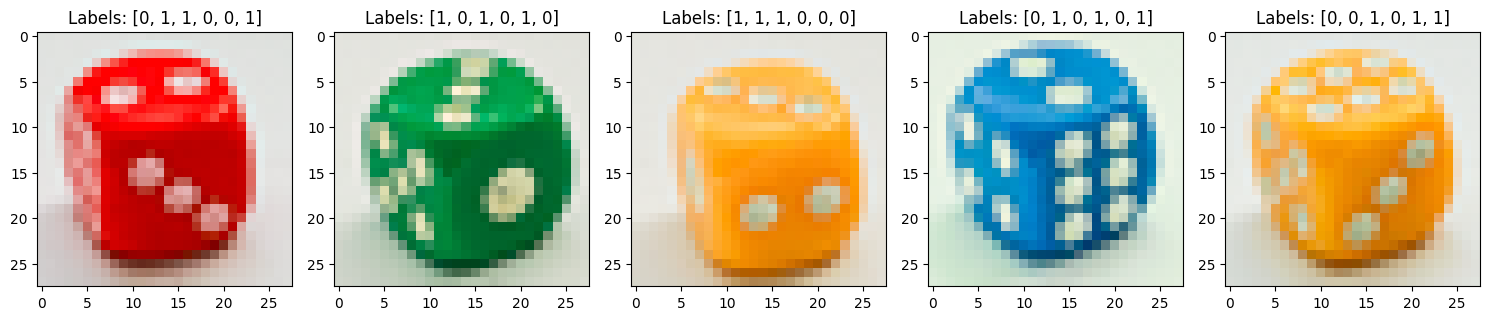

In [121]:
import matplotlib.pyplot as plt
import torch

from examples.datasets import create_dice_datasets

batch_size = 16

train_loader, test_loader, _, (mean, std), _ = create_dice_datasets(batch_size)

images, labels = next(iter(test_loader))

# show the first n images
n = 5
fig, axes = plt.subplots(1, n, figsize=(3*n, 3))

for i, ax in enumerate(axes[:n]):
    img = images[i].permute(1, 2, 0) # convert from (C, H, W) to (H, W, C)

    # denormalise
    img = img * torch.as_tensor(std) + torch.as_tensor(mean)
    img = img.clamp(0, 1)

    ax.imshow(img)
    ax.set_title(f"Labels: {labels[i].int().tolist()}")

plt.tight_layout()
plt.show()

Now let's create a very simple, small CNN model.
As the die has six possible faces, we build the model so that it will output a $6$-element vector, and we consider label $i$ to be predicted, if the $i$th element in the output vector is positive.

Note the lack of a final SoftMax or Sigmoid etc. layer, which will make it easier for us to later use formal verification tools.

In [122]:
class DiceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 4, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=3, stride=2, padding=1)
        self.fc1 = nn.Linear(8 * 7 * 7, 16)
        self.fc2 = nn.Linear(16, 6)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

N = DiceNet().to(device)

print(f"number of trainable model parameters: {sum(p.numel() for p in N.parameters() if p.requires_grad)}")

number of trainable model parameters: 6798


## 2. Specifying the logical constraint

Now we can go ahead and define our logical constraint. Our network is deliberately small because we do not want to care so much about the network providing very accurate predictions. But we want to make sure the network only predicts physically possible combinations.
There are multiple ways to express this; let's start with a simple version, requiring the network to not predict at the same time two faces that are on opposite sides of the die, i.e. our constraint is

> *"do not predict both 1 and 6, and do not predict both 2 and 5, and do not predict both 3 and 4"*.

Remember that label $i$ is predicted if the $i$th element of output vector $y$ is positive, i.e. "label $i$ is predicted" translates to $y_i>0$. Consequently, "label $i$ is not predicted" translates to $y_i\le 0$.

When creating a constraint, we derive from the base `Constraint` class and assign a `Precondition` (such as an `EpsilonBall`) and a `Postcondition` (our logical constraint for the outputs).

To express our logical constraint, we work with an abstract `Logic` object that provides some common operations:

*   comparison: `LEQ(x, y)`, `EQ(x, y)` and `NEQ(x, y)`, `LT(x, y)` and `GT(x, y)`,
*   $n$-ary conjunction and disjunction `AND(*xs)` and `OR(*xs)`,
*   implication `IMPL(x, y)` and equivalence `EQUIV(x, y)`,

which allow us to express the constraint independent from the choice of differentiable logic.

In [123]:
from property_driven_ml.constraints import Constraint, EpsilonBall
from property_driven_ml.constraints.postconditions import Postcondition
from property_driven_ml.logics import Logic

class DiceConstraint(Constraint):
    def __init__(self, device: torch.device, epsilon: float, std: Tuple[float, ...] | float | None = None):
        super().__init__(device)
        self.precondition = EpsilonBall(device, epsilon, std)
        self.postcondition = DiceConstraintPostcondition(device)

class DiceConstraintPostcondition(Postcondition):
    """
    Enforces that the network may not predict faces at the same time that are
    on opposite sides of the die (e.g. faces 1 and 6).
    """

    def __init__(self, device: torch.device):
        self.device = device
        self.zero = torch.tensor(0.0, device=self.device)
        self.opposingFacePairs = [(0, 5), (1, 4), (2, 3)]
        self.allFaces = list(range(6))
        self.one = torch.tensor(1.0, device=self.device)
        self.three = torch.tensor(3.0, device=self.device)

    def get_postcondition(self, N: torch.nn.Module, x_adv: torch.Tensor) -> Callable[[Logic], torch.Tensor]:
        y_adv = N(x_adv)

        return lambda logic: logic.AND(
             *[
                 logic.OR(
                     logic.LEQ(y_adv[:, i], self.zero),  # either label i is not predicted ...
                     logic.LEQ(y_adv[:, j], self.zero),  # ... or label j is not predicted
                 )
                 for i, j in self.opposingFacePairs
            ],
            # Check that the count of predicted faces is greater than zero
            logic.GT(torch.sum(logic.LEQ(self.zero, y_adv), dim=1), self.zero),
            # Check that the count of predicted faces is less than or equal to three (a maximum of three are predicted)
            logic.LEQ(torch.sum(logic.LEQ(self.zero, y_adv), dim=1), self.three),
            # Check that 3 is less than or equal to the count of the predicted faces (a minimum of three are predicted)
            logic.LEQ(self.three, torch.sum(logic.LEQ(self.zero, y_adv), dim=1))

        )

## 3. Setting up the training process

Now we are ready to set up property-driven training components such as choice of differentiable logic to use in training, and creating an oracle that will provide us with adversarial examples (or: constraint counterexamples).
We use [AutoPGD](https://arxiv.org/abs/2003.01690), an improved, adaptive attack based on PGD. We also create an optimiser of our choice (ADAM is usually a good start) as well as an adaptive loss balancer, [GradNorm](https://arxiv.org/abs/1711.02257).

In [124]:
# choice of differentiable logic: choose from DL2, GoedelFuzzyLogic, ...
logic = logics.DL2()

# create instance of our constraint, specifying epsilon
epsilon = 8 / 255
constraint = DiceConstraint(device, epsilon=epsilon, std=std)

# attack parameters, i.e. number of iterations and random restarts
steps = 5
restarts = 5

oracle = training.APGD(logic, device, steps, restarts, mean=mean, std=std)

# create optimiser and specify learning rate
optimiser = optim.Adam(N.parameters(), lr=5e-3)

# create adaptive loss balancer
grad_norm = training.GradNorm(N, device, optimiser, lr=1e-3, alpha=1.5)

Before we do the training, let us first define the metrics with which we evaluate our network's performance, following [Casadio et al.](https://link.springer.com/chapter/10.1007/978-3-031-13185-1_11) for the constraint satisfaction metrics.

*   **Prediction accuracy:** here, we use Hamming score, which measures per-label accuracy.
*   **Constraint accuracy:** constraint satisfaction on samples randomly drawn from $\mathbb{B}(\mathbf{x};\epsilon)$.
*   **Constraint security:** constraint satisfaction on adversarial samples from $\mathbb{B}(\mathbf{x};\epsilon)$ found via PGD.

## 4. Training & evaluating the model

We will first train for a number of epochs, and only evaluate the network's performance in the very end.

In [125]:
epochs = 10

for epoch in range(epochs):
  N.train()

  total_pred_loss, total_pred_acc = 0.0, 0.0
  total_random_loss, total_random_sat = 0.0, 0.0
  total_constraint_loss, total_constraint_sat = 0.0, 0.0

  num_batches = 0

  for _, (x, y) in enumerate(train_loader):
    x, y = x.to(device), y.to(device)

    # standard forward pass
    pred = N(x)

    # prediction loss & Hamming score
    pred_loss = F.binary_cross_entropy_with_logits(pred, y)
    total_pred_loss += pred_loss.item()
    correct = torch.mean(((pred > 0.0).float() == y).float().mean(dim=1))
    total_pred_acc += correct

    # evaluate constraint accuracy (constraint satisfaction on random samples)
    with torch.no_grad():
      loss_random, sat_random = constraint.eval(N, x, None, y, logic, reduction="mean")
      total_random_loss += loss_random.item()
      total_random_sat += sat_random.item()

    # evaluate constraint security (satisfaction on adversarial samples)
    x_adv = oracle.attack(N, x, y, constraint)
    loss_adv, sat_adv = constraint.eval(N, x, x_adv, y, logic, reduction="mean")
    total_constraint_loss += loss_adv.item()
    total_constraint_sat += sat_adv.item()

    optimiser.zero_grad(set_to_none=True)
    grad_norm.balance(pred_loss, loss_adv)

  grad_norm.renormalise()

  # Epoch summary
  print(
      f"Epoch {epoch + 1} -- "
      f"Pred Accuracy: {(total_pred_acc / len(train_loader)):.4f} "
      f"Pred Loss: {(total_pred_loss / len(train_loader)):.4f}  "
      f"Constraint Accuracy: {(total_random_sat / len(train_loader)):.4f} "
      f"Constraint Loss: {(total_constraint_loss / len(train_loader)):.4f} "
      f"Constraint Security: {(total_constraint_sat / len(train_loader)):.4f} "
  )

GradNorm weights=tensor([1., 1.])
Epoch 1 -- Pred Accuracy: 0.5165 Pred Loss: 0.6948  Constraint Accuracy: 0.9779 Constraint Loss: 0.0004 Constraint Security: 0.9743 
GradNorm weights=tensor([1.0003, 0.9997])
Epoch 2 -- Pred Accuracy: 0.5172 Pred Loss: 0.6916  Constraint Accuracy: 0.9081 Constraint Loss: 0.0001 Constraint Security: 0.9044 
GradNorm weights=tensor([1.0004, 0.9996])
Epoch 3 -- Pred Accuracy: 0.5202 Pred Loss: 0.6905  Constraint Accuracy: 1.0000 Constraint Loss: 0.0000 Constraint Security: 1.0000 
GradNorm weights=tensor([1.0014, 0.9986])
Epoch 4 -- Pred Accuracy: 0.5515 Pred Loss: 0.6874  Constraint Accuracy: 0.9853 Constraint Loss: 0.0003 Constraint Security: 0.9779 
GradNorm weights=tensor([1.0051, 0.9949])
Epoch 5 -- Pred Accuracy: 0.5705 Pred Loss: 0.6817  Constraint Accuracy: 0.9596 Constraint Loss: 0.0007 Constraint Security: 0.9485 
GradNorm weights=tensor([1.0150, 0.9850])
Epoch 6 -- Pred Accuracy: 0.6219 Pred Loss: 0.6656  Constraint Accuracy: 0.8603 Constraint 

Lastly, we can evaluate how the final model performs.

In [126]:
oracle_test = training.APGD(logics.LeakyLogic(), device, steps=70, restarts=40, mean=mean, std=std)

N.eval()

with torch.no_grad():
    x, y = next(iter(test_loader))
    x, y = x.to(device), y.to(device)

    # evaluate prediction accuracy
    predictions = (N(x) > 0.0).float()
    accuracy = torch.sum((predictions == y).float().mean(dim=1)) / x.size(0)

    # evaluate constraint accuracy (constraint satisfaction on random samples)
    loss_random, sat_random = constraint.eval(N, x, None, y, logic, reduction="mean")

    # evaluate constraint security (satisfaction on adversarial samples)
    x_adv = oracle_test.attack(N, x, y, constraint)
    _, constraint_sat = constraint.eval(N, x, x_adv, None, logics.BooleanLogic(), reduction="mean")

    print("Final Evaluation:")
    print(f"  Prediction Accuracy: {accuracy:.4f}")
    print(f"  Constraint Accuracy: {sat_random.item():.4f}")
    print(f"  Constraint Security: {constraint_sat.item():.4f}")

Final Evaluation:
  Prediction Accuracy: 0.6042
  Constraint Accuracy: 1.0000
  Constraint Security: 0.3750


And we can also have a closer look at an adversarial example:

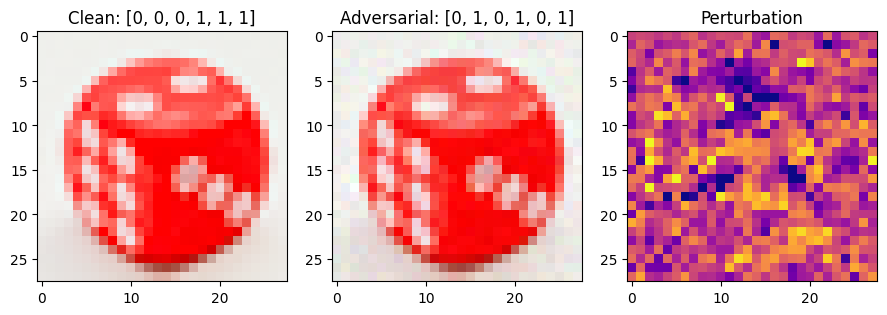

In [127]:
# visualise adverarial example and predictions
pred_adv = N(x_adv)
idx = 10

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

pairs = [(x, pred, "Clean"), (x_adv, pred_adv, "Adversarial")]

for (img, preds, title), ax in zip(pairs, axes):
  img = img[idx].cpu().permute(1, 2, 0) # convert from (C, H, W) to (H, W, C)
  img = img * torch.as_tensor(std) + torch.as_tensor(mean)
  img = img.clamp(0, 1)

  ax.imshow(img)
  ax.set_title(f"{title}: {(preds[0] > 0.0).int().tolist()}")

delta = (x_adv - x).cpu().mean(dim=1, keepdim=True)
axes[2].imshow(delta[idx].permute(1, 2, 0), cmap="plasma")
axes[2].set_title("Perturbation")

plt.tight_layout()
plt.show()

## 5. Action Tasks

Walk through the example, try small changes, and run short experiments:

*   What happens if you change the PGD parameters (steps, number of random restarts)?
*   The network might learn a shortcut and vacuously satisfy the constraint "do not predict two opposite faces at the same time" by predicting no faces at all. Can you make changes to the constraint that to this behaviour?
*   Can you come up with any other meaningful constraints, such as a modified version of the epsilon-delta robustness one we have seen in the lectures, or something like "always predict exactly three faces"?

Lastly, think about how you might apply the library in your own work (e.g. Alsomitra).

In [128]:
#### Action tasks

# What happens when I change the PGD Parameters?

# Base - steps = 5, restarts = 5

# Final Evaluation:
  # Prediction Accuracy: 0.5521
  # Constraint Accuracy: 1.0000
  # Constraint Security: 0.8750

# Change 1 - steps = 10, restarts = 10

# Final Evaluation:
  # Prediction Accuracy: 0.7708
  # Constraint Accuracy: 1.0000
  # Constraint Security: 0.7500

# Change 2 - steps = 5, restarts = 10

# Final Evaluation:
  # Prediction Accuracy: 0.6458
  # Constraint Accuracy: 1.0000
  # Constraint Security: 0.8750

# Change 3 - steps = 10, restarts = 5

# Final Evaluation:
  # Prediction Accuracy: 0.7188
  # Constraint Accuracy: 1.0000
  # Constraint Security: 0.6875

# Change 4 - steps = 20, restarts = 20

# Final Evaluation:
  # Prediction Accuracy: 0.7917
  # Constraint Accuracy: 1.0000
  # Constraint Security: 0.6875

# Change 4 - steps = 6, restarts = 6

# Final Evaluation:
  # Prediction Accuracy: 0.8021
  # Constraint Accuracy: 1.0000
  # Constraint Security: 0.5625


### Ensuring can't just predict no face - steps = 5, restarts = 5

# Final Evaluation:
  # Prediction Accuracy: 0.6042
  # Constraint Accuracy: 1.0000
  # Constraint Security: 0.3750

### Ensuring can't just predict no face and always exactly 3 faces - steps = 5, restarts = 5

# Final Evaluation:
     # Prediction Accuracy: 0.5208
     # Constraint Accuracy: 0.0000
     # Constraint Security: 0.0000

# Because model no longer optimising for minimisation of prediction error, penalised also for violating logical properties.
# Trying to balance making accurate predictions and satisfying the logical constraints



## Further Reading



### Verification with Vehicle

We can also have a look at how verification of our dice model would look like.
First, let's look at some interesting parts of the Vehicle specification.

The biggest difference compared to the MNIST example is that now we are not dealing with single-channel images anymore.
So, firstly, we need to define the type of RGB images as $3$-channel images.

```
-- original RGB image (3 channels) with pixel values in [0, 255]
type UnnormalisedImage = Tensor Real [3, 28, 28]
```

Next, since we applied mean-std normalisation to our images for the network to work best, we also need to make sure to reflect this in the Vehicle specification so that we can reason about properties in problem space.

```
-- normalisation:
mean : Vector Real 3
mean = [0.7232479453086853, 0.7257601618766785, 0.6415771842002869]

std : Vector Real 3
std = [0.32942402362823486, 0.24738003313541412, 0.2831753194332123]


-- x_norm = (x - mean) / std
normalise : UnnormalisedImage -> NormalisedImage
normalise x =
  foreach c .
    foreach h .
      foreach w .
        let m = mean ! c in
        let s = std ! c in
          ( (x ! c ! h ! w) - m ) / s
```

Our last building block is to have a notion of "the network predicts label $i$":

```
-- a label i is predicted if its logit y_i > 0
predicts : UnnormalisedImage -> Index 6 -> Bool
predicts x i = ( classifier (normalise x) ) ! i > 0
```

And lastly, our property "do not predict two faces that are on opposite sides of the die" boils down to

```
oppositeFacePairs : Vector (Vector (Index 6) 2) 3
oppositeFacePairs = [ [0, 5], [1, 4], [2, 3] ]

oppositeFaces : UnnormalisedImage -> Bool
oppositeFaces image = forall perturbation .
  let perturbedImage = image + perturbation in
    boundedByEpsilon perturbation and validImage perturbedImage =>
      (forall p .
        let pair = oppositeFacePairs ! p in
          not ( (predicts perturbedImage (pair ! 0) ) and (predicts perturbedImage (pair ! 1) ) )
      )
```

where predicates like `boundedByEpsilon` and `validImage` should already be familar from previous Vehicle examples (only extended to multi-channel images here).

---

The GitHub repository contains the full code necessary to actually run formal verification on the dice dataset, including:

*   the [code to save the network to `.onnx`](https://github.com/property-driven-ml/property-driven-ml/blob/feat/add-dice-dataset/main.py#L405-L421),
*   the [code to convert images to `.idx`](https://github.com/property-driven-ml/property-driven-ml/blob/feat/add-dice-dataset/examples/dice_to_idx.py),
*   the [full Vehicle specification](https://github.com/property-driven-ml/property-driven-ml/blob/feat/add-dice-dataset/examples/dice.vcl),
*  as well as [example invocations of the Vehicle tool](https://github.com/property-driven-ml/property-driven-ml/blob/feat/add-dice-dataset/examples/run_dice.sh).

### Training Alsomitra Controller Networks

The library already contains the necessary code for training Alsomitra networks.

For example, the second Alsomitra constraint, defined as

> *If the drone is close to the line and at an appropriate pitch angle, the neural network output will be intermediate*

i.e. as

$$\forall\mathbf{x}\ldotp\ \underbrace{\mathsf{closeToLine}(\mathbf{x}_0,\mathbf{x})}_{-2 - x^{(\mathbf{x}_0)} \le y^{(\mathbf{x})} \le 2 - x^{(\mathbf{x}_0)}}\wedge\ \underbrace{\mathsf{appropriatePitchAngle}(\mathbf{x})}_{-0.786 \le \theta^{(\mathbf{x})} \le -0.747}\implies 0.184\le f(\mathbf{x})\le 0.19,$$

is implemented as

```python
class AlsomitraProperty2Constraint(Constraint):
    def __init__(
        self,
        device: torch.device,
        y_threshold: float = 2.0,                                # closeToLine
        theta_threshold: Tuple[float, float] = (-0.786, 0.747),  # appropriatePitchAngle
        bounds_output: Tuple[float, float] = (0.184, 0.19),      # bounds on f(x)
    ):
        """
        Args:
            y_threshold: Threshold for the y input.
            theta_threshold: Tuple specifying (min, max) bounds for the theta input.
        """
        super().__init__(device)
        self.precondition = AlsomitraProperty2(device, y_threshold, theta_threshold)
        self.postcondition = AlsomitraOutputPostcondition(device, lo=bounds_output[0], hi=bounds_output[1])
```

where the interesting part, namely the input region specification, is implemented as

```python
class AlsomitraProperty2(AlsomitraBase):
    def __init__(self, device: torch.device, y_threshold: float, theta_thresholds: Tuple[float, float]) -> None:
        """
        Args:
            y_threshold: Threshold for the y-coordinate relative to x.
            theta_thresholds: Tuple defining (min, max) bounds for the theta angle.
        """
        super().__init__(device)
        self.y_threshold = y_threshold
        self.theta_thresholds = theta_thresholds

    def get_bounds(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            lo, hi: Tensors defining lower and upper bounds for the Alsomitra input region.
        """

        x_problem = self.denormalize(x)

        lo = x_problem.clone()
        hi = x_problem.clone()

        # closeToLine
        lo[:, self.y] = -self.y_threshold - x_problem[:, self.x]
        hi[:, self.y] = self.y_threshold - x_problem[:, self.x]

        # appropriatePitchAngle
        lo[:, self.theta] = self.theta_thresholds[0]
        hi[:, self.theta] = self.theta_thresholds[1]

        return self.apply_domain_bounds(lo, hi)
```

---

The full code is on GitHub, including the [Alsomitra dataset itself](https://github.com/property-driven-ml/property-driven-ml/blob/feat/add-dice-dataset/examples/datasets/alsomitra.py), all the [Alsomitra constraints](https://github.com/property-driven-ml/property-driven-ml/blob/feat/add-dice-dataset/src/property_driven_ml/constraints/constraints.py#L272C1-L360C75), all [Alsomitra input space definitions](https://github.com/property-driven-ml/property-driven-ml/blob/feat/add-dice-dataset/src/property_driven_ml/constraints/preconditions.py#L186C1-L411C48), and the [Alsomitra output constraint implementation](https://github.com/property-driven-ml/property-driven-ml/blob/feat/add-dice-dataset/src/property_driven_ml/constraints/postconditions.py#L170C1-L257C14).